<a href="https://colab.research.google.com/github/ralucamicu/FineTuning-LLMs-for-Cybersecurity-Knowledge/blob/master/finetune_secbert_spearphishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
assert torch.cuda.is_available(), "No GPU detected. Runtime → Change runtime type → T4 GPU."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}")
print(f"VRAM: {gpu.total_memory / 1024**3:.1f} GB")

GPU: Tesla T4
VRAM: 14.6 GB


In [2]:
%%capture
!pip install --quiet --upgrade transformers 'datasets==2.14.7' accelerate scikit-learn seaborn

In [3]:
import json, re, random, email, os, mailbox
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

random.seed(3407)
np.random.seed(3407)
torch.manual_seed(3407)
print("Setup complete.")

Setup complete.


In [4]:
EVAL_PATH = "/content/eval_set.jsonl"
existing_eval = None
if os.path.exists(EVAL_PATH):
    existing_eval = []
    with open(EVAL_PATH, "r") as f:
        for line in f:
            existing_eval.append(json.loads(line))
    print(f"✓ Found existing eval set: {len(existing_eval)} samples (skipping rebuild)")
else:
    print("No existing eval_set.jsonl found — will rebuild from sources below.")

No existing eval_set.jsonl found — will rebuild from sources below.


In [5]:
if existing_eval is None:
    !rm -rf /content/MachineLearningPhishing
    !git clone --depth=1 https://github.com/diegoocampoh/MachineLearningPhishing.git /content/MachineLearningPhishing

    MBOX_PATH = "/content/MachineLearningPhishing/code/resources/emails-phishing.mbox"

    def extract_body(msg):
        body = ""
        if msg.is_multipart():
            for part in msg.walk():
                if part.get_content_type() == "text/plain":
                    try:
                        payload = part.get_payload(decode=True)
                        if payload:
                            body += payload.decode("utf-8", errors="ignore")
                    except Exception:
                        continue
        else:
            try:
                payload = msg.get_payload(decode=True)
                if payload:
                    body = payload.decode("utf-8", errors="ignore")
            except Exception:
                body = msg.get_payload() or ""
        if not body.strip() and msg.is_multipart():
            for part in msg.walk():
                if part.get_content_type() == "text/html":
                    try:
                        payload = part.get_payload(decode=True)
                        if payload:
                            body = payload.decode("utf-8", errors="ignore")
                            break
                    except Exception:
                        continue
        return body.strip()

    mbox = mailbox.mbox(MBOX_PATH)
    nazario_emails = []
    for msg in mbox:
        body = extract_body(msg)
        subject = msg.get("Subject", "") or ""
        if len(body) > 80:
            full_text = f"Subject: {subject}\n\n{body}"
            nazario_emails.append(full_text)
    print(f"Parsed Nazario phishing: {len(nazario_emails)} emails")
else:
    nazario_emails = None
    print("Skipping Nazario parse (eval set already loaded)")

Cloning into '/content/MachineLearningPhishing'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 36 (delta 2), reused 34 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 9.06 MiB | 10.62 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Parsed Nazario phishing: 2249 emails


In [6]:
if existing_eval is None:
    enron = load_dataset("SetFit/enron_spam", split="test")
    enron_df = enron.to_pandas()
    ham_df = enron_df[enron_df["label"] == 0].copy()

    def build_enron_text(row):
        subj = row.get("subject", "") or ""
        body = row.get("text", "") or row.get("message", "") or ""
        return f"Subject: {subj}\n\n{body}".strip()

    ham_df["full_text"] = ham_df.apply(build_enron_text, axis=1)
    ham_df = ham_df[ham_df["full_text"].str.len().between(100, 5000)].reset_index(drop=True)

    N_PER_CLASS = 300
    MAX_EMAIL_CHARS = 2000

    phishing_sample = random.sample(nazario_emails, min(N_PER_CLASS, len(nazario_emails)))
    ham_sample = random.sample(ham_df["full_text"].tolist(), min(N_PER_CLASS, len(ham_df)))

    eval_data = (
        [{"text": t, "label": 1, "label_str": "PHISHING", "source": "nazario"} for t in phishing_sample] +
        [{"text": t, "label": 0, "label_str": "SAFE",     "source": "enron"}   for t in ham_sample]
    )
    random.shuffle(eval_data)
    for item in eval_data:
        if len(item["text"]) > MAX_EMAIL_CHARS:
            item["text"] = item["text"][:MAX_EMAIL_CHARS] + " [truncated]"

    with open(EVAL_PATH, "w") as f:
        for item in eval_data:
            f.write(json.dumps(item) + "\n")

    print(f"Eval set frozen: {len(eval_data)} samples saved to {EVAL_PATH}")
else:
    eval_data = existing_eval
    print(f"Using existing eval set: {len(eval_data)} samples")

# Show class balance
labels = [r["label"] for r in eval_data]
print(f"  Phishing (1): {sum(labels)}  |  Safe (0): {len(labels) - sum(labels)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Repo card metadata block was not found. Setting CardData to empty.


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Eval set frozen: 600 samples saved to /content/eval_set.jsonl
  Phishing (1): 300  |  Safe (0): 300


In [7]:
train_raw = load_dataset("ealvaradob/phishing-dataset",
                          "combined_reduced")
print(f"Splits: {list(train_raw.keys())}")
print(f"Train size (full): {len(train_raw['train'])}")

Generating train split: 0 examples [00:00, ? examples/s]

Splits: ['train']
Train size (full): 77677


In [8]:
N_TRAIN_PER_CLASS = 3000
MAX_EMAIL_CHARS = 2000

train_df = train_raw["train"].to_pandas()
train_df["text"] = train_df["text"].astype(str)

phish_train = train_df[train_df["label"] == 1].sample(N_TRAIN_PER_CLASS, random_state=3407)
benign_train = train_df[train_df["label"] == 0].sample(N_TRAIN_PER_CLASS, random_state=3407)
train_sampled = pd.concat([phish_train, benign_train]).sample(frac=1, random_state=3407).reset_index(drop=True)

train_sampled["text"] = train_sampled["text"].str.slice(0, MAX_EMAIL_CHARS)

val_df = train_sampled.sample(frac=0.1, random_state=3407)
train_split = train_sampled.drop(val_df.index).reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train:      {len(train_split)} samples ({(train_split['label']==1).sum()} phish + {(train_split['label']==0).sum()} benign)")
print(f"Validation: {len(val_df)} samples ({(val_df['label']==1).sum()} phish + {(val_df['label']==0).sum()} benign)")

Train:      5400 samples (2695 phish + 2705 benign)
Validation: 600 samples (305 phish + 295 benign)


In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "jackaduma/SecBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = 2,
    id2label   = {0: "SAFE", 1: "PHISHING"},
    label2id   = {"SAFE": 0, "PHISHING": 1},
)
model = model.to("cuda")
print(f"Loaded {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"VRAM after load: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/336M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at jackaduma/SecBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded jackaduma/SecBERT
Parameters: 83,452,418
VRAM after load: 0.31 GB


In [10]:
@torch.no_grad()
def predict_batch(texts, batch_size=16):
    """Run SecBERT classification on a list of texts. Returns predicted labels (0/1)."""
    model.eval()
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt",
        ).to("cuda")
        logits = model(**enc).logits
        preds.extend(logits.argmax(dim=-1).cpu().numpy().tolist())
    return preds


def evaluate_on_set(eval_records, name="eval"):
    """Evaluate SecBERT on the held-out set. Returns metrics dict + per-sample results."""
    texts  = [r["text"] for r in eval_records]
    y_true = np.array([r["label"] for r in eval_records])

    print(f"Running {name} on {len(texts)} samples...")
    y_pred = np.array(predict_batch(texts, batch_size=16))

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics = {
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "fpr":       float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

    results = []
    for r, p in zip(eval_records, y_pred):
        results.append({
            "label":         int(r["label"]),
            "label_str":     r["label_str"],
            "predicted":     int(p),
            "predicted_str": "PHISHING" if p == 1 else "SAFE",
            "is_correct":    int(p == r["label"]),
            "source":        r.get("source", ""),
            "email_excerpt": r["text"][:120],
        })

    print(f"\n{name} metrics:")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"  {k:10s}: {v:.4f}")
        else:
            print(f"  {k:10s}: {v}")
    return metrics, results

In [11]:
print("=" * 60)
print("BASELINE — SecBERT with untrained classification head")
print("=" * 60)
baseline_metrics, baseline_results = evaluate_on_set(eval_data, name="baseline (Nazario+Enron)")

BASELINE — SecBERT with untrained classification head
Running baseline (Nazario+Enron) on 600 samples...

baseline (Nazario+Enron) metrics:
  accuracy  : 0.5083
  precision : 0.5042
  recall    : 0.9967
  f1        : 0.6697
  fpr       : 0.9800
  tn        : 6
  fp        : 294
  fn        : 1
  tp        : 299


In [12]:
from transformers import (TrainingArguments, Trainer, DataCollatorWithPadding,
                          EarlyStoppingCallback)

# Convert pandas DataFrames to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_split[["text", "label"]])
val_ds   = Dataset.from_pandas(val_df[["text", "label"]])


def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=512)


train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn,   batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0),
    }


training_args = TrainingArguments(
    output_dir              = "secbert-spearphishing-outputs",
    num_train_epochs        = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate           = 2e-5,
    weight_decay            = 0.01,
    warmup_ratio            = 0.1,
    eval_strategy           = "epoch",
    save_strategy           = "epoch",
    load_best_model_at_end  = True,
    metric_for_best_model   = "f1",
    greater_is_better       = True,
    fp16                    = True,
    logging_steps           = 20,
    report_to               = "none",
    save_total_limit        = 1,
    seed                    = 3407,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    tokenizer       = tokenizer,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=1)],
)

Map:   0%|          | 0/5400 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

/tmp/ipykernel_3992/2134114884.py:50: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [13]:
print(f"VRAM used before training: {torch.cuda.memory_reserved()/1024**3:.2f} GB")
trainer_stats = trainer.train()
print(f"\nPeak VRAM during training: {torch.cuda.max_memory_reserved()/1024**3:.2f} GB")
print(f"Training time: {trainer_stats.metrics['train_runtime']/60:.1f} minutes")

VRAM used before training: 0.77 GB


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.321900,0.268935,0.893333,0.897690,0.891803,0.894737
2,0.258100,0.229687,0.906667,0.933798,0.878689,0.905405
3,0.151800,0.258626,0.908333,0.913907,0.904918,0.909390



Peak VRAM during training: 2.93 GB
Training time: 4.3 minutes


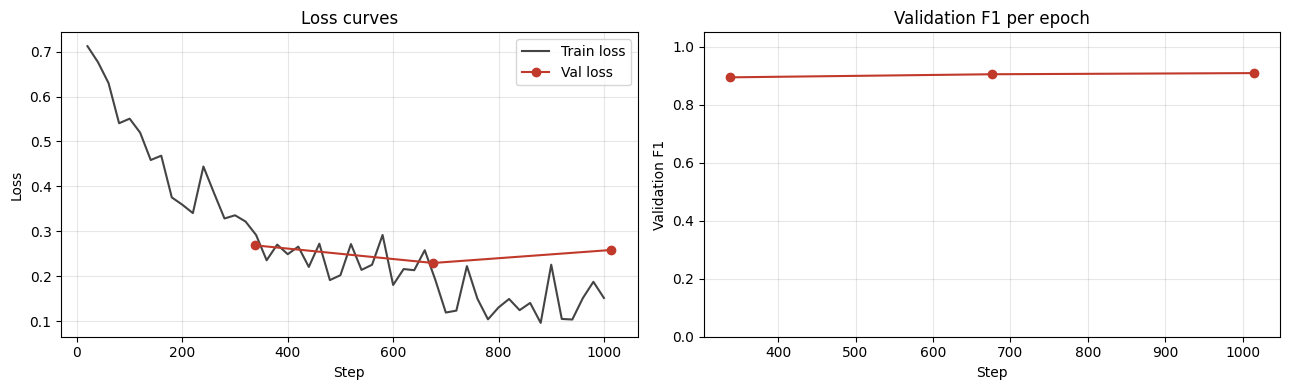

Saved as secbert_training_curves.png


In [14]:
loss_history = trainer.state.log_history
train_losses = [(h["step"], h["loss"]) for h in loss_history if "loss" in h and "eval_loss" not in h]
val_metrics  = [(h["step"], h["eval_loss"], h["eval_f1"]) for h in loss_history if "eval_loss" in h]

if train_losses:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    steps, vals = zip(*train_losses)
    ax1.plot(steps, vals, linewidth=1.5, color="#444", label="Train loss")
    if val_metrics:
        vsteps, vlosses, _ = zip(*val_metrics)
        ax1.plot(vsteps, vlosses, "o-", color="#c0392b", label="Val loss")
    ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
    ax1.set_title("Loss curves"); ax1.legend(); ax1.grid(alpha=0.3)

    if val_metrics:
        vsteps, _, vf1s = zip(*val_metrics)
        ax2.plot(vsteps, vf1s, "o-", color="#c0392b")
        ax2.set_xlabel("Step"); ax2.set_ylabel("Validation F1")
        ax2.set_title("Validation F1 per epoch"); ax2.grid(alpha=0.3)
        ax2.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.savefig("secbert_training_curves.png", dpi=150)
    plt.show()
    print("Saved as secbert_training_curves.png")

In [15]:
print("=" * 60)
print("AFTER FINE-TUNING — SecBERT on Nazario + Enron")
print("=" * 60)
ft_metrics, ft_results = evaluate_on_set(eval_data, name="fine-tuned (Nazario+Enron)")

AFTER FINE-TUNING — SecBERT on Nazario + Enron
Running fine-tuned (Nazario+Enron) on 600 samples...

fine-tuned (Nazario+Enron) metrics:
  accuracy  : 0.7267
  precision : 0.8617
  recall    : 0.5400
  f1        : 0.6639
  fpr       : 0.0867
  tn        : 274
  fp        : 26
  fn        : 138
  tp        : 162


In [16]:
rows = []
for metric in ["accuracy", "precision", "recall", "f1", "fpr"]:
    base_v = baseline_metrics[metric]
    ft_v   = ft_metrics[metric]
    rows.append({
        "Metric":     metric.upper() + (" (lower=better)" if metric == "fpr" else ""),
        "Baseline":   f"{base_v:.4f}",
        "Fine-tuned": f"{ft_v:.4f}",
        "Δ":          f"{ft_v - base_v:+.4f}",
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))
df_compare.to_csv("secbert_before_after.csv", index=False)
print("\nSaved as secbert_before_after.csv")

            Metric Baseline Fine-tuned       Δ
          ACCURACY   0.5083     0.7267 +0.2183
         PRECISION   0.5042     0.8617 +0.3575
            RECALL   0.9967     0.5400 -0.4567
                F1   0.6697     0.6639 -0.0057
FPR (lower=better)   0.9800     0.0867 -0.8933

Saved as secbert_before_after.csv


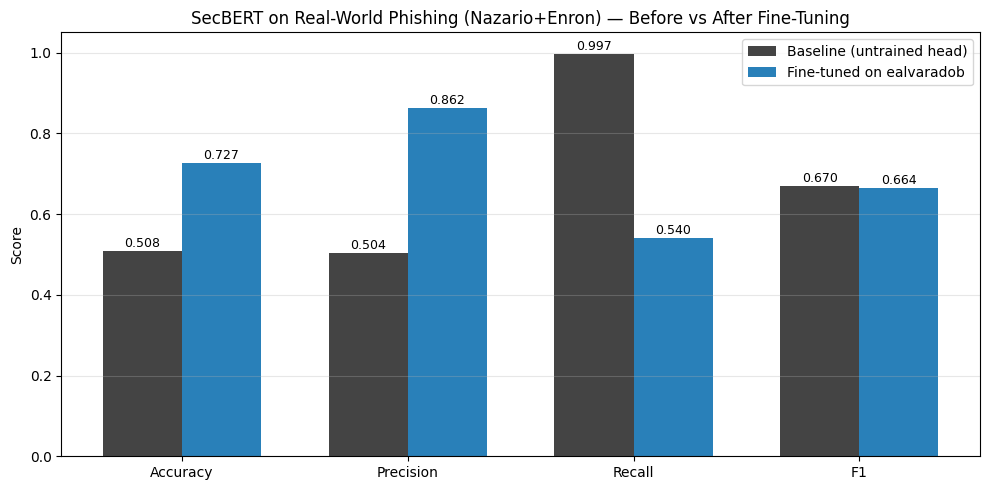

In [17]:
metric_names = ["Accuracy", "Precision", "Recall", "F1"]
base_vals = [baseline_metrics[m.lower()] for m in metric_names]
ft_vals   = [ft_metrics[m.lower()]       for m in metric_names]

x = np.arange(len(metric_names)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, base_vals, width, label="Baseline (untrained head)", color="#444")
b2 = ax.bar(x + width/2, ft_vals,   width, label="Fine-tuned on ealvaradob", color="#2980b9")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("SecBERT on Real-World Phishing (Nazario+Enron) — Before vs After Fine-Tuning")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("secbert_before_after.png", dpi=150)
plt.show()

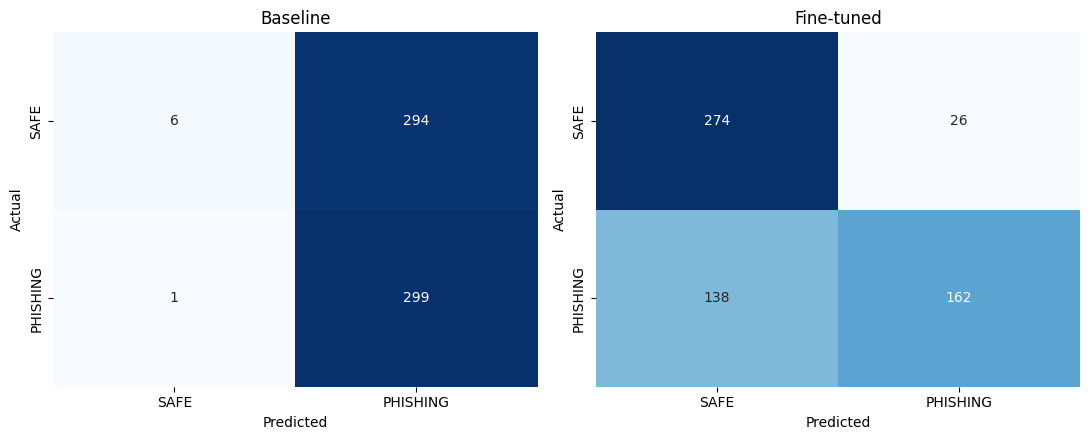

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

def plot_cm(ax, metrics, title):
    cm = np.array([[metrics["tn"], metrics["fp"]],
                   [metrics["fn"], metrics["tp"]]])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["SAFE", "PHISHING"],
                yticklabels=["SAFE", "PHISHING"], cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)

plot_cm(axes[0], baseline_metrics, "Baseline")
plot_cm(axes[1], ft_metrics,       "Fine-tuned")
plt.tight_layout()
plt.savefig("secbert_confusion_matrices.png", dpi=150)
plt.show()

In [19]:
for source in ["nazario", "enron"]:
    subset = [r for r in ft_results if r["source"] == source]
    if not subset:
        continue
    y_true = np.array([r["label"] for r in subset])
    y_pred = np.array([r["predicted"] for r in subset])
    correct = (y_true == y_pred).sum()
    print(f"{source.upper():10s}: {correct}/{len(subset)} = {correct/len(subset):.2%}")

NAZARIO   : 162/300 = 54.00%
ENRON     : 274/300 = 91.33%


In [20]:
SAVE_PATH = "/content/secbert-spearphishing-final"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Saved fine-tuned SecBERT to {SAVE_PATH}")

pd.DataFrame(baseline_results).to_csv("secbert_baseline_per_sample.csv", index=False)
pd.DataFrame(ft_results).to_csv("secbert_finetuned_per_sample.csv", index=False)
print("Saved secbert_baseline_per_sample.csv and secbert_finetuned_per_sample.csv")

Saved fine-tuned SecBERT to /content/secbert-spearphishing-final
Saved secbert_baseline_per_sample.csv and secbert_finetuned_per_sample.csv
